In [4]:
# from fastapi import FastAPI
# from pydantic import BaseModel
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import davies_bouldin_score


# import joblib
# from sklearn.neighbors import NearestNeighbors

In [31]:
import re

df = pd.read_csv("data/cars.csv")

#df = df[df["fuel"] == "Electric"]
df.columns = df.columns.str.strip().str.lower()

def strip_trim_from_name(row, name_col="name", trim_col="trim"):
    name = str(row.get(name_col, "") or "")
    trim = row.get(trim_col, "")
    if pd.isna(trim) or trim is None:
        return name

    trim = str(trim).strip()
    if trim == "":
        return name

    # escape regex metacharacters in trim
    esc = re.escape(trim)

    # pattern:
    #  - match " - TRIM" or "— TRIM" or ": TRIM"
    #  - match "(TRIM)"
    #  - match trim as a whole word (so single-letter 'S' won't match 'Soul')
    pattern = rf'(?i)(?:\s*[-–—:]\s*{esc}|\s*\(\s*{esc}\s*\)|\b{esc}\b)'

    # remove occurrences that match the pattern
    new_name = re.sub(pattern, ' ', name)

    # collapse multiple spaces and trim leading/trailing whitespace
    new_name = re.sub(r'\s+', ' ', new_name).strip()

    return new_name

pattern = r"Audi"


'\n      \n        $2,437 off MSRP! Buy with confidence knowing you have our $500 Best Price Guarantee: Simply put, no other dealer will beat our price on any of our in-stock units. Price does not include Tax, Title, License, Destination Fee and $229 Documentation Fee. Factory MSRP: $35,935Price includes $99 wheel locks, $299 Pulse, $399 Waypoint, and $149 Door edge guard & cup protector2024 Jeep Compass Limited Baltic Gray Metallic Clearcoat 4WD 2.0L I4 DOHC Price does not include Tax, Title, License, Destination Fee and Documentation Fee; Price does include: $500 - 2024 DJR National Retail Consumer Cash 24CR1. Exp. 06/03/2024 $500 - 2024 JEEP SFS Bonus Cash GLCR1. Exp. 06/03/2024  Price includes $946 of dealer added accessories.\n      \n    All New Vehicle pricing includes Rebate,Owner Loyalty Bonus Cash,Credit Union Bonus Cash and Great Lakes Bonus Cash zip code must be verified.'

In [7]:
#df2 = pd.read_csv('Safercar_data.csv')

# Convert to numeric (in case of 'Not Rated' or strings)
#df2['OVERALL_STARS'] = pd.to_numeric(df2['OVERALL_STARS'], errors='coerce')

# Drop rows with missing or invalid ratings
#df2 = df2.dropna(subset=['OVERALL_STARS'])

# Group by make and calculate the average
#average_ratings = df2.groupby('MAKE')['OVERALL_STARS'].mean().sort_values(ascending=False).to_dict()


#print(average_ratings)


In [24]:
import pandas as pd
import requests
from IPython.display import HTML

# Take input and filter
#make = input("Enter make: ").strip().lower()
#model = input("Enter model: ").strip().lower()
#yr = input("Enter model year: ").strip().lower()

#matches = df2[(df2['MODEL'].str.lower().str.contains(model, na=False)) 
             # & (df2['MODEL_YR'] == int(yr))][['MAKE', 'MODEL', 'MODEL_YR', 'OVERALL_STARS']]
#if matches.shape[0] > 0:
   # display(matches)
#else:
  #  print("Requested car not found")

#display(HTML(f'<a href=https://cars.usnews.com/cars-trucks/{make}/{model}/{yr} target="_blank">{yr} {make.capitalize()} {model.capitalize()}</a>'))

In [33]:
import re

def clean_model_name(model: str) -> str:
    # Define forbidden words
    forbidden_words = {
        "se", "le", "xe", "xle", "ls", "lxs", "ex", "limited", "ultimate", "advanced", "premium", "standard", "range", "touring",
        "sport", "luxury", "pure", "electric", "twin", "performance", "plus", "base", "select", "light", "long", 
        "gt", "a-spec", "edition", "platinum", "sel", "2lt", "lt", "sxt", "sv", "s", "14t", "l", "latitude", "preferred", "active", 
        "sle", "r/t", "1500", "2500", "3500"
    }
    
    # Normalize and split
    words = model.lower().split()
    
    # Filter out forbidden words and numeric tokens (integers or decimals)
    filtered_words = [
        w for w in words
        if w not in forbidden_words and not re.match(r"\d+(\.\d+)", w)
    ]
        
    # Join back into slug
    return "-".join(filtered_words)

# Test cases
#print(clean_model_name("Ioniq 5 SE Standard Range"))                   # → "ioniq-5"
#print(clean_model_name("C40 Recharge Pure Electric Twin Ultimate"))   # → "c40-recharge"
#print(clean_model_name("Electrified GV70 Advanced"))                  # → "electrified-gv70"
#print(clean_model_name("CR-V 1.5T Touring"))                           # → "cr-v"
#print(clean_model_name("CX-30 2.5 S Premium"))     
#print(clean_model_name("GMC Terrain SLE"))

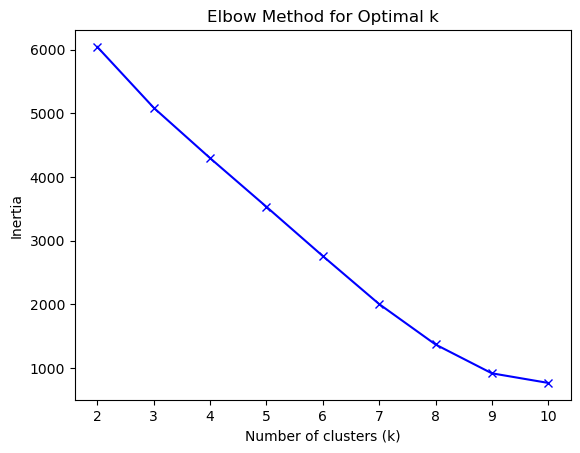

                 price  cylinders     doors  body_Convertible  body_Hatchback  \
category                                                                        
0         46784.937255   4.686275  4.000000               0.0             0.0   
1         60106.155172   6.114943  3.747126               0.0             0.0   
2         34218.686275   4.588235  4.000000               0.0             0.0   
3         38040.000000   4.000000  2.000000               1.0             0.0   
4         50988.875000   5.750000  3.875000               0.0             0.0   
5         41418.500000   4.000000  4.000000               0.0             1.0   

          body_Minivan  body_Passenger Van  body_Pickup Truck  body_SUV  \
category                                                                  
0             0.001961                 0.0           0.000000  0.996078   
1             0.000000                 0.0           0.833333  0.005747   
2             0.000000                 0.0         

In [48]:
features = ["cylinders", "body", "doors"]
X = df[features].copy()

X = pd.get_dummies(X, columns=["body"], drop_first=True)

encoded_features = X.columns.tolist()
#("Encoded features:", encoded_features)

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []
K = range(2, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, 'bx-')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

# Cluster (k found using elbow method)
kmeans = KMeans(n_clusters=6, random_state=42)
df["category"] = kmeans.fit_predict(X_scaled)

# Add the new encoded columns to the original df
for col in X.columns:
    df[col] = X[col]

# Group by clusters
print(df.groupby("category")[encoded_features].mean())

# Mapping of cluster numbers -> labels
cluster_labels = {
    0: "Standard Premium SUV",
    1: "High-End Truck/Performance Vehicle",
    2: "New Sedan (Commuter/Mid-Range)",
    3: "Budget New Compact Sedan",
    4: "New Efficient Hatchback/Compact",
    5: "New Premium Van/High-Power Utility"
}

# Apply mapping
df["category_label"] = df["category"].map(cluster_labels)

# Preview
print(df[["name", "price", "mileage", "cylinders", "year", "doors", "category", "category_label"]].head(30))
dbi = davies_bouldin_score(X, df["category"])
print("Davies-Bouldin Index:", round(dbi, 3))

